# Step 1: Single-Sample SCIMAP Processing (No PC)

**Purpose:** Process one multiplexed imaging sample (from MCMICRO output) through the full SCIMAP spatial proteomics workflow — from raw quantification to phenotyped, ROI-filtered AnnData ready for downstream comparison.

## What this notebook does

1. **Configuration & setup** — Define sample ID, genotype, paths, and marker lists. 
   All downstream file paths are built automatically from these settings.

2. **Data loading** — Import the MCMICRO cellRing quantification CSV and convert it to 
   an AnnData object (the core data structure for SCIMAP). A checkpoint `.h5ad` file is 
   saved immediately.

3. **Visual QC** — Open the tissue image in napari for manual inspection; generate 2D 
   density plots of marker pairs to assess signal distributions before gating.

4. **Gating & rescaling** — Load manually-set gate thresholds (from Minerva Gater), then 
   rescale all marker intensities to a 0–1 scale relative to each gate.

5. **Phenotyping** — Apply rule-based cell-type assignment using a phenotyping CSV that 
   defines marker logic for each cell type. Validate results with a heatmap and a napari 
   overlay.

6. **ROI selection** — Interactively draw 4 regions of interest (ROIs) in napari, then 
   combine them into a single unified ROI column and filter to keep only cells within 
   drawn regions.

7. **Cleanup & export** — Remove unclassified ("Unknown") cells, add genotype metadata, 
   and save the final AnnData as `.h5ad`. Generate a stacked bar chart comparing cell-type 
   composition across ROIs.

## Inputs
- `<sample_id>--unmicst_cellRing.csv` — per-cell marker quantification from MCMICRO
- `<sample_id>.ome.tif` — registered tissue image
- `<sample_id>_gates.csv` — manual gate thresholds (one per marker)
- `phenotyping_workflow_simple.csv` — cell-type assignment rules

## Outputs
- `adata_<sample_id>.h5ad` — final processed AnnData (phenotyped, ROI-filtered, genotype-labeled)
- `isogenic_phenotypecounts_<sample_id>.csv` — cell-type count table
- Validation plots (heatmap, stacked bar chart)

## Requirements
- Python 3.10 environment with: scimap, anndata, scanpy, napari, tifffile, pandas, numpy, seaborn, matplotlib
- Manual steps: gate thresholds must be set in Minerva Gater before the rescaling step; ROIs are drawn interactively in napari

In [83]:
## Import all required libraries
import sys # system utilities, not really used directly
import os # file navigation on your computer
import pandas as pd # handles tables (dataframes)
import anndata as ad # data structure used by scimap
import scanpy as sc # single-cell analysis funcs
import seaborn as sns; sns.set(color_codes=True) # makes Seaborn color defaults nicer
import matplotlib.pyplot as plt # plotting
from scipy import stats # statistics funcs
import numpy as np # arrays and math
from datetime import date # automatically adds today's date to file names

import warnings 
warnings.filterwarnings('ignore') # hide the warnings to keep outputs cleaner

# Import Scimap
import scimap as sm

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


In [84]:

# -------------------------------------------------------------------
## ‼️ UPDATE‼️ this cell every time you run a new sample
# -------------------------------------------------------------------
# Who/what is this sample
sample_id = '40_ST_KO' # Update your sample barcode -- must match MCMICRO folder name
exp = 'KS_2' # Update your experiment name, used in output file names
date = date.today() # Automatically updates to today's date
genotype  = 'KO' # Update exp. condition

# Where is the data
working_dir = '/Users/elizabethxiu/Downloads/KS_2' # Please update root folder containing all the samples

# How many ROIs to draw
n_rois = 2 # Update to match how many you want. ‼️NOTE‼️ if you change this you also need to:
           #  1) add/remove ROI drawing cells accordingly
            #  2) update the np.where block in the 4th to last cell accordingly. (tricky, can avoid by just keeping 4 ROIs)

# Names for each ROI you'll draw (in order: ROI1, ROI2, ROI3...)
# Update this list to match how many ROIs you're drawing and what to call them
roi_names = ['Tumor', 'Spleen']  # ‼️UPDATE THIS‼️ —- one name per ROI you plan to draw

# Which markers to show in validation heatmap? 
heatmap_markers = [
    'CD11c',
    'F480',
    'CD11b',
    'CD3e',
    'CD8',
    'CD4',
    'CD163',
    'CD45',
    'CD206',
    'PDL1',
    'pan-Cytokeratin',
    'CD86',
    'Ecadherin',
    'CD45R',
    'Ly6G_1',
    'Ly6G_2',
    'CD31',
    'NK1.1',
    'TREM2',
    'PD1',
    'CXCL9',
]  # Update if needed

# Print a summary to make sure everything looks right 
print("Configuration summary below:")
print(f"  Sample    : {sample_id}")
print(f"  Genotype  : {genotype}")
print(f"  Root directory  : {working_dir}")
print(f"  Date    : {date}")

Configuration summary below:
  Sample    : 40_ST_KO
  Genotype  : KO
  Root directory  : /Users/elizabethxiu/Downloads/KS_2
  Date    : 2026-06-16


In [85]:
# -------------------------------------------------------------------
## Everything below built automatically, don't edit!
# -------------------------------------------------------------------

# Output folder names
analysis_dir  = os.path.join(working_dir, 'analysis') # .join() handles slashes better, more clean and easy
counts_dir    = os.path.join(analysis_dir, 'scimap_results', 'counts_scimap')
adata_out_dir = os.path.join(analysis_dir, 'scimap_results', 'adata_tocombine')

# Input file path names built from sample_id so you don't have to edit manually
cellring_csv     = os.path.join(working_dir, sample_id, 'quantification',
                                f'{sample_id}--unmicst_cellRing.csv')
tif_path         = os.path.join(working_dir, sample_id, 'registration',
                                f'{sample_id}.ome.tif')
gates_file       = os.path.join(working_dir, sample_id,
                                f'{sample_id}_gates.csv')
phenotyping_file = os.path.join(working_dir, sample_id, f'phenotyping_workflow_{sample_id}.csv')

# Output file path names
counts_csv       = os.path.join(counts_dir,f'isogenic_phenotypecounts_{sample_id}.csv')
adata_final      = os.path.join(adata_out_dir,f'adata_{sample_id}.h5ad')
adata_checkpoint = os.path.join(analysis_dir,f'{date}_{exp}.h5ad')

# Check that all required input file names actually exist on disk

print("Checking input files:")
all_good = True
for label, path in [('CellRing CSV', cellring_csv),
                    ('TIF image',    tif_path),
                    ('Gates file',   gates_file),
                    ('Phenotyping',  phenotyping_file)]:
    if os.path.exists(path): # checks if file/folder actually exists on your computer - True if yes, False if not
        print(f"{label} is here!")
    else:
        print(f" {label} is missing")
        print(f"Expected at: {path}")
        all_good = False

if all_good:
    print("\n All files found. Ready to run!")
else:
    print("\n Please fix missing files before continuing.")


Checking input files:
CellRing CSV is here!
TIF image is here!
Gates file is here!
Phenotyping is here!

 All files found. Ready to run!


In [86]:
## Create all the actual output folder PATHS

for folder in [analysis_dir, counts_dir, adata_out_dir]:
    os.makedirs(folder, exist_ok=True) # create the folder; if it already exists, move on
    print(f"Ready: {folder}")
    
# Navigate to the working directory and set it
os.chdir(working_dir)
print(f"\nWorking directory set to {os.getcwd()}") # prints whatever the current working directory has been set to to make sure it worked

Ready: /Users/elizabethxiu/Downloads/KS_2/analysis
Ready: /Users/elizabethxiu/Downloads/KS_2/analysis/scimap_results/counts_scimap
Ready: /Users/elizabethxiu/Downloads/KS_2/analysis/scimap_results/adata_tocombine

Working directory set to /Users/elizabethxiu/Downloads/KS_2


## ‼️ SHORTCUT: load existing processed data
If you have already completed Step 1, you may run the cell below INSTEAD of everything below (loading CSV, gating, phenotyping, napari, ROI drawing)

In [87]:
## ‼️ SHORTCUT: load existing processed data 
# After running this cell (and above cells) you can skip straight to the markerCorrelation cell.

adata = ad.read_h5ad(adata_checkpoint) # full dataset, all cells, has phenotypes and gates, but NO ROIs
                                       # This is what was saved right after phenotyping

adata1 = ad.read_h5ad(adata_final) # ROI filtered dataset, has phenotypes, ROIs, + genotype 
                                   # This is the finished product from the end of Step 1

pheno_label = 'phenotype' # must be defined up here again because the cell that defines it later on is down below (and would be skipped)

print(f'adata loaded: {adata.n_obs:,} cells')
print(f'adata1 loaded: {adata1.n_obs:,} cells')
print(f'Cell types: {adata1.obs[pheno_label].value_counts().to_string()}') # counts of each unique cell type
print('Ready! You can now skip to the heatmap + stacked bar plot cell, markerCorrelation cell, or final stacked bar per ROI cell.')

adata loaded: 1,814,113 cells
adata1 loaded: 1,000,659 cells
Cell types: phenotype
CD4 T cells         407648
M2 Macs             300838
Dendritic cells     198455
CD8 T cells          39023
PDL1 cells           33672
Tumor cells          17788
M1 Macs               1905
Epithilial cells      1283
neutrophils             39
PD1 cells                8
Ready! You can now skip to the heatmap + stacked bar plot cell, markerCorrelation cell, or final stacked bar per ROI cell.


## Full Analysis
If you are not taking the shortcut above, proceed with the full analysis below:

In [49]:
## Load the cellRing CSV and convert to AnnData (scimap format)

print(f"Loading: {cellring_csv}")

adata = sm.pp.mcmicro_to_scimap([cellring_csv]) # scimap preprocessing feature that converts the MCMICRO csv to anndata

# Save a checkpoint immediately after loading so if anything crashes later you can reload this .h5ad file
os.chdir(analysis_dir)
adata.write(adata_checkpoint, compression=None) # save adata_checkpoint to computer (compression=None faster for big files)

print(f"\n Data loaded and saved!")
print(f"Cells detected: {adata.n_obs:,}") # number of observations (cells)
print(f"Markers: {adata.n_vars}") #  number of variables (markers)
print(f"Marker names: {list(adata.var_names)}") # list of marker names
print(f"Checkpoint: {adata_checkpoint}")

Loading: /Users/elizabethxiu/Downloads/KS_2/41_ST_KO/quantification/41_ST_KO--unmicst_cellRing.csv
Loading 41_ST_KO--unmicst_cellRing.csv

 Data loaded and saved!
Cells detected: 1,814,113
Markers: 24
Marker names: ['AF488', 'AF555', 'AF647', 'CD11c', 'F480', 'CD11b', 'CD3e', 'CD8', 'CD4', 'CD163', 'CD45', 'CD206', 'PDL1', 'pan-Cytokeratin', 'CD86', 'Ecadherin', 'CD45R', 'Ly6G_1', 'CD31', 'Ly6G_2', 'NK1.1', 'TREM2', 'PD1', 'CXCL9']
Checkpoint: /Users/elizabethxiu/Downloads/KS_2/analysis/2026-06-16_KS_2.h5ad


In [50]:
# ----------------------------
# Renaming cell labels for more clarity + consistency
# ----------------------------

# Rename imageid column for ease
# Ensure the new name matches the CSV filename used to generate adata
rename = {sample_id: [f'{sample_id}--unmicst_cellRing']}
adata = sm.hl.rename(adata, rename, from_column='imageid', to_column='imageid') # scimamp function takes dictionary new name : old name and does find and replace
                                                                                # staying within the imageid column
print(f"imageid shortened to: '{sample_id}'")

# Add Treatment_Group column 
rename = {exp: [sample_id]}
adata = sm.hl.rename(adata, rename, from_column='imageid', to_column='Treatment_Group') # filling in a new treatment_group column with exp variable
print(f"Treatment_Group column added: '{exp}'")

# Clean up the cell row names (index)
indices = (adata.obs.index.str.slice(0, len(sample_id)) + "_" + adata.obs.index.str.slice((len(sample_id) + 19),)) # applied to every string (cell name) in the list
adata.obs.index = indices # list of row labels/names for each cell
print(f"Cell names cleaned, example: '{adata.obs.index[0]}'")

# Save updated adata, same checkpoint file but now w/ clean labels

os.chdir(analysis_dir)
adata.write(adata_checkpoint, compression=None)
print(f"\nCheckpoint saved!")
adata.obs # View adata


Renaming 41_ST_KO--unmicst_cellRing to 41_ST_KO
imageid shortened to: '41_ST_KO'
Renaming 41_ST_KO to KS_2
Treatment_Group column added: 'KS_2'
Cell names cleaned, example: '41_ST_KO_1'

Checkpoint saved!


,X_centroid,Y_centroid,Area,MajorAxisLength,MinorAxisLength,Eccentricity,Solidity,Extent,Orientation,CellID,imageid,Treatment_Group
41_ST_KO_1,1362.942177,941.068027,294.0,22.698251,16.701724,0.677182,0.945338,0.668182,-0.981501,1,41_ST_KO,KS_2
41_ST_KO_2,3210.018692,416.116822,214.0,23.695441,12.217013,0.856838,0.880658,0.620290,1.137061,2,41_ST_KO,KS_2
41_ST_KO_3,3193.640394,417.211823,203.0,21.770063,12.281050,0.825689,0.935484,0.709790,1.479184,3,41_ST_KO,KS_2
41_ST_KO_4,2267.378378,920.940878,592.0,34.594840,22.206930,0.766776,0.951768,0.725490,-1.254012,4,41_ST_KO,KS_2
41_ST_KO_5,3235.023810,1181.095238,168.0,18.316859,12.069458,0.752208,0.903226,0.622222,-1.038778,5,41_ST_KO,KS_2
...,...,...,...,...,...,...,...,...,...,...,...,...
41_ST_KO_1814109,31385.338542,30740.062500,192.0,17.852243,13.837791,0.631803,0.945813,0.761905,1.511087,1814109,41_ST_KO,KS_2
41_ST_KO_1814110,31396.503448,30745.406897,145.0,16.125014,12.127351,0.659068,0.878788,0.604167,-0.426805,1814110,41_ST_KO,KS_2
41_ST_KO_1814111,31336.033149,30977.801105,181.0,16.820330,13.734882,0.577254,0.928205,0.709804,-1.201758,1814111,41_ST_KO,KS_2
41_ST_KO_1814112,32311.122034,31519.155932,295.0,23.359336,16.275350,0.717325,0.933544,0.670455,0.499055,1814112,41_ST_KO,KS_2


## Inspect distribution of markers in raw image

Before we assign cell type markers, we will first review the image in Napari image viewer to do a quick visual QC that the image loads and the markers are visible. 

We will also make a density plot of marker pairs to assess signal distributions. This is another visual QC to ensure mutually exclusive markers and co-expressing markers follow expected distributions. 

In [51]:
#Open napari to see and inspect raw tissue image before gating

# Set the working directory and select which sample(s) to view in Napari
os.chdir(working_dir)

subset_to_use = adata.obs['imageid'].unique()[0] # returns the first unique value in the imageid column, if only have one sample this is just the sampleid

marker_names = list(adata.var_names) # convert marker names stored in adata from anndata to normal list

print(f"Opening napari for {subset_to_use}")
print(f"Image: {tif_path}")
print("Close napari when done")


sm.pl.image_viewer( # scimap plotting function, opens the tissue image w/ each marker as a layer
    tif_path, # path to the tif tissue image
    adata, # the anndata object (marker names + cell info)
    point_size=15,  # size of dots if overlaying cell positions
    imageid='imageid', # which column in adata.obs identifies the sample
    subset=subset_to_use, # which sample to display
    markers= None # load markers and DNA
)


Opening napari for 41_ST_KO
Image: /Users/elizabethxiu/Downloads/KS_2/41_ST_KO/registration/41_ST_KO.ome.tif
Close napari when done


Density plot: pan-Cytokeratin (x) versus CD45 (y)


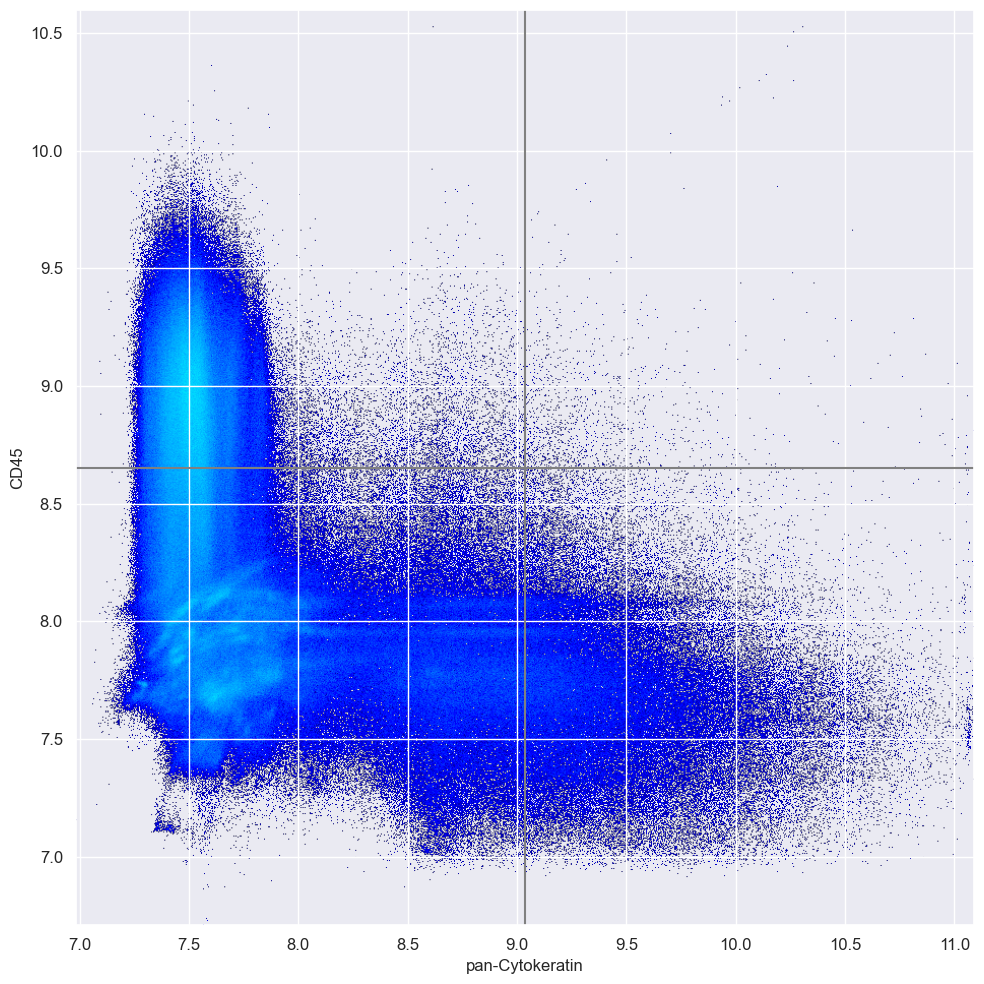

In [52]:
## Density plot to see marker distributions before gating

# ‼️UPDATE ‼️ -- Change these 2 markers to look at different combinations
marker_x = 'pan-Cytokeratin'   # the x axis marker
marker_y = 'CD45'     # the y axis marker

subset_to_use = adata.obs['imageid'].unique()[0] # get sample name again
print(f"Density plot: {marker_x} (x) versus {marker_y} (y)")


sm.pl.densityPlot2D( # another scimap plotting function, plots every cell as point on 2D grid 
    adata,
    marker_x, # x-axis marker (positional argument no keyword needed)
    markerB=marker_y, # y-axis marker (keyword argument)
    layer=None, # use raw unscaled data (None means use adata.X directly)
    imageid='imageid', # column that identifies the sample
    subset=subset_to_use, # only plot this sample
    ncols=None, # num of columns if making multiple plots (None = auto)
    cmap='jet', # color map; blue, green, yellow, red is low to high density
    figsize=(10, 10), # width by height of the plot (inches)
    fontsize=None, # font size for labels (None = default)
    dpi=100, # resolution of the plot (dots/inch)
    xticks=None, # custom x-axis tick marks (None = auto)
    yticks=None # custom y-axis tick marks (None = auto)
)

In [53]:
## Point to the gating and phenotyping files (these come from the configuration cell at the beginning) 

pheno_label = 'phenotype' # stores the name of the new column (assigned cell type for each cell)

# Again, this loop checks if a file actually exists at that path, returns True if found and False if not
for label, path in [('Gates',       gates_file), # csv with one row per marker and threshold intensity (set manually) 
                    ('Phenotyping', phenotyping_file)]: # csv with if/then rules for assigning cell type
    status = 'All good!' if os.path.exists(path) else 'Missing!!'
    print(f"{status} --> {label}: {path}")

print(f"\n Cell type labels will be stored in {pheno_label}")

All good! --> Gates: /Users/elizabethxiu/Downloads/KS_2/41_ST_KO/41_ST_KO_gates.csv
All good! --> Phenotyping: /Users/elizabethxiu/Downloads/KS_2/41_ST_KO/phenotyping_workflow_41_ST_KO.csv

 Cell type labels will be stored in phenotype


## ‼️ NOTE:‼️

There is a manual step that must be done at some point before the following cell is run.

### Open Minerva Gater to set gates for each slide before proceeding.
1) Download Minerva Gater for your appropriate operating system (Windows or Mac): https://github.com/labsyspharm/gater
2) Open Gater. I recommend storing the .exe file in your SCIMAP working directory so it's easy to find. 
4) Go to http://localhost:8000 in browser
5) In the Gater header, select "Upload," check MCMICRO, enter path to your sample folder
6) Set gates for each marker visually, then type in the values in your gates csv

In [54]:
## Load the gates CSV file
manual_gate = pd.read_csv(gates_file) # pandas function reads CSV file and converst to dataframe 
manual_gate = manual_gate.rename(columns={'Gate': 'markers', 'BDBAT0085': 'gates'}) # these are the names scimap will be looking for 

# This is a dictionary inside adata for storing extra info
# storing gates here can help keep track of the thresholds used
adata.uns['gates'] = manual_gate # Makes an entry inside the dictionary

print("Gates loaded:")
print(manual_gate.to_string(index=False)) # prints the data frame as text without row numbers

Gates loaded:
        markers  gates
           DNA2   7.11
          CD11c   8.91
           F480   9.21
          CD11b   9.26
           CD3e   7.58
            CD8   8.46
            CD4   9.24
          CD163   1.08
           CD45   7.34
          CD206   8.41
           PDL1   9.24
pan-Cytokeratin   9.08
           CD86   7.69
      Ecadherin   8.32
          CD45R   8.33
         Ly6G_1  10.66
           CD31  11.01
         Ly6G_2   8.22
          NK1.1   7.21
          TREM2  10.94
            PD1   8.01
          CXCL9   9.13


In [55]:
## Rescale all marker intensities using gate thresholds
# All markers end up on a 0-1 scale relative to their gate threshold
# Note that this permanently changes adata.X so the raw values are replaced

print("Rescaling marker intensities...")

# Another scimap preprocessing function, this is what normalizes each marker's intensity values relative to threshold
adata = sm.pp.rescale(adata, gate=manual_gate) 

print("Rescaling complete! adata.X now contains normalized 0–1 values.")


Rescaling marker intensities...
Running GMM for image: 41_ST_KO
Applying GMM to markers: AF488, AF555, AF647

Scaling Image: 41_ST_KO
Scaling AF488 (gate: 7.330)
Scaling AF555 (gate: 6.663)
Scaling AF647 (gate: 7.222)
Scaling CD11c (gate: 8.910)
Scaling F480 (gate: 9.210)
Scaling CD11b (gate: 9.260)
Scaling CD3e (gate: 7.580)
Scaling CD8 (gate: 8.460)
Scaling CD4 (gate: 9.240)
Scaling CD163 (gate: 1.080)
Scaling CD45 (gate: 7.340)
Scaling CD206 (gate: 8.410)
Scaling PDL1 (gate: 9.240)
Scaling pan-Cytokeratin (gate: 9.080)
Scaling CD86 (gate: 7.690)
Scaling Ecadherin (gate: 8.320)
Scaling CD45R (gate: 8.330)
Scaling Ly6G_1 (gate: 10.660)
Scaling CD31 (gate: 11.010)
Scaling Ly6G_2 (gate: 8.220)
Scaling NK1.1 (gate: 7.210)
Scaling TREM2 (gate: 10.940)
Scaling PD1 (gate: 8.010)
Scaling CXCL9 (gate: 9.130)
Rescaling complete! adata.X now contains normalized 0–1 values.


In [56]:
## Assign a cell type identity to every cell 

phenotype_rules = pd.read_csv(phenotyping_file) #pandas function reads the phenotyping rules file into a DataFrame
print(phenotype_rules.to_string(index=False))

# scimap tool function reads the rules in phenotype_rules and applies them to EVERY cell in adata !
# label=pheno_label says what to name the new column it adds to adata.obs
adata = sm.tl.phenotype_cells(adata, phenotype=phenotype_rules, label=pheno_label)

print(f"\n Phenotyping complete!")
print(f"   Column {pheno_label} has been added to adata.obs")
adata.obs

    Unnamed: 0       Unnamed: 1  DNA2  CD11c   F480  CD11b   CD3e    CD8    CD4  CD163   CD45  CD206   PDL1 pan-Cytokeratin   CD86 Ecadherin  CD45R  Ly6G_1  CD31 Ly6G_2  NK1.1  TREM2    PD1  CXCL9
           All     Immune cells   NaN anypos anypos anypos anypos anypos anypos    NaN anypos anypos    NaN             NaN anypos       NaN anypos     NaN   NaN anypos anypos    NaN    NaN    NaN
  Immune cells    Myeloid cells   NaN anypos anypos anypos    NaN    NaN    NaN    NaN    NaN anypos    NaN             NaN anypos       NaN    NaN     NaN   NaN    NaN    NaN    NaN    NaN    NaN
  Immune cells   Lymphoid cells   NaN    NaN    NaN    NaN anypos anypos anypos    NaN    NaN    NaN    NaN             NaN    NaN       NaN anypos     NaN   NaN    NaN anypos    NaN    NaN    NaN
  Immune cells      neutrophils   NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN             NaN    NaN       NaN    NaN     NaN   NaN allpos    NaN    NaN    NaN    NaN
           All 

,X_centroid,Y_centroid,Area,MajorAxisLength,MinorAxisLength,Eccentricity,Solidity,Extent,Orientation,CellID,imageid,Treatment_Group,phenotype
41_ST_KO_1,1362.942177,941.068027,294.0,22.698251,16.701724,0.677182,0.945338,0.668182,-0.981501,1,41_ST_KO,KS_2,Macrophages
41_ST_KO_2,3210.018692,416.116822,214.0,23.695441,12.217013,0.856838,0.880658,0.620290,1.137061,2,41_ST_KO,KS_2,Dendritic cells
41_ST_KO_3,3193.640394,417.211823,203.0,21.770063,12.281050,0.825689,0.935484,0.709790,1.479184,3,41_ST_KO,KS_2,Dendritic cells
41_ST_KO_4,2267.378378,920.940878,592.0,34.594840,22.206930,0.766776,0.951768,0.725490,-1.254012,4,41_ST_KO,KS_2,Macrophages
41_ST_KO_5,3235.023810,1181.095238,168.0,18.316859,12.069458,0.752208,0.903226,0.622222,-1.038778,5,41_ST_KO,KS_2,Macrophages
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41_ST_KO_1814109,31385.338542,30740.062500,192.0,17.852243,13.837791,0.631803,0.945813,0.761905,1.511087,1814109,41_ST_KO,KS_2,Immune cells
41_ST_KO_1814110,31396.503448,30745.406897,145.0,16.125014,12.127351,0.659068,0.878788,0.604167,-0.426805,1814110,41_ST_KO,KS_2,Immune cells
41_ST_KO_1814111,31336.033149,30977.801105,181.0,16.820330,13.734882,0.577254,0.928205,0.709804,-1.201758,1814111,41_ST_KO,KS_2,Immune cells
41_ST_KO_1814112,32311.122034,31519.155932,295.0,23.359336,16.275350,0.717325,0.933544,0.670455,0.499055,1814112,41_ST_KO,KS_2,Immune cells


In [57]:
## Count how many cells were assigned to each cell type

# This counts how many times each unique value appears in the "phenotype" column from most to least and returns as a 2 column table
counts_df = (
    adata.obs['phenotype']
    .value_counts() # return pandas series, basically shows index --> value
    .reset_index() # return as 2 column table format

    
) 

counts_df.columns = ['phenotype', 'count'] # rename the 2 columns in the table
print(counts_df)

counts_df.to_csv(counts_csv, index=False) # save to the counts_csv file defined in config.


           phenotype    count
0            M1 Macs  1137278
1    Dendritic cells   199907
2      Myeloid cells   131328
3        Macrophages    85605
4   Epithilial cells    81666
5       Immune cells    39214
6        Tumor cells    32273
7        CD8 T cells    30159
8        CD4 T cells    21567
9            M2 Macs    20736
10    Lymphoid cells    16313
11           T cells    12355
12        PDL1 cells     3110
13          NK cells     1110
14       neutrophils      803
15           Unknown      645
16         PD1 cells       44


In [58]:
# Save checkpoint immediately after phenotyping
# This allows us to reload adata with phenotypes in future runs
# without having to redo gating and phenotyping again
os.chdir(analysis_dir)
adata.write(adata_checkpoint, compression=None)
print(f'Checkpoint saved with phenotypes to: {adata_checkpoint}')
print(f'Columns now saved: {list(adata.obs.columns)}')

Checkpoint saved with phenotypes to: /Users/elizabethxiu/Downloads/KS_2/analysis/2026-06-16_KS_2.h5ad
Columns now saved: ['X_centroid', 'Y_centroid', 'Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'Solidity', 'Extent', 'Orientation', 'CellID', 'imageid', 'Treatment_Group', 'phenotype']


## Validate Phenotyping

The next step is to validate how well our gates accurately captured cells positive for each marker, and how well our phenotyping workflow accurately classified cell types. 

We will plot the distribution of the phenotypes and inspect them visually in Napari. 

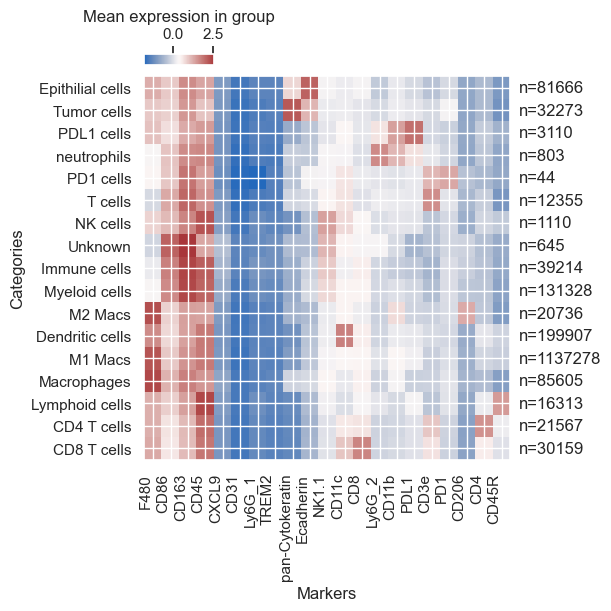

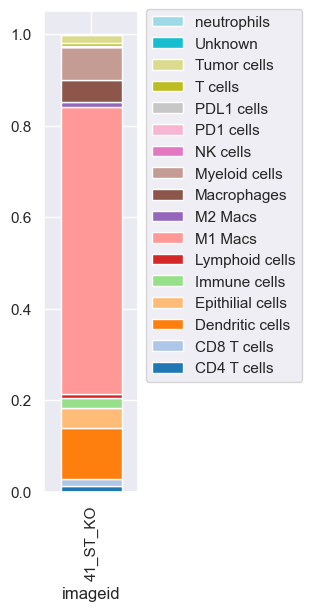

In [59]:
## Two ways of visually validating phenotyping results - sanity check
## Run both + check  outputs before moving on to ROI drawing

# Plot 1: Heat map
# Shows avg marker intensity per cell type

# A new scimap plotting function
sm.pl.heatmap(
    adata,
    groupBy=pheno_label, # rows of the heat map = cell types, grouped by phenotype column
    subsetMarkers=heatmap_markers,  # only show these markers as columns; set in configuration cell, update there if needed
    standardScale='column', # Standardize a dimension between 0 and 1 (subtract the minimum and divide each by its maximum). We are scaling each marker (column).
    showPrevalence=True, # add % of total cells next to each row label
    figsize=(6, 6),
    saveDir=None,
    fileName=None)

# Plot 2: Stacked bar chart
# Shows what % of cells in this sample are each cell type


# New scimap plotting function
sm.pl.stacked_barplot(
    adata,
    x_axis='imageid', # one bar per sample 
    y_axis=pheno_label, # stack the bar by cell type
    method='percent', #percentages, not raw counts so bar always adds to 100%
    plot_tool='matplotlib', # this module is used to render the plot
    matplotlib_cmap='tab20', # color scheme, 20 dif colors
    figsize=(3, 6),
    edgecolor='white'
)

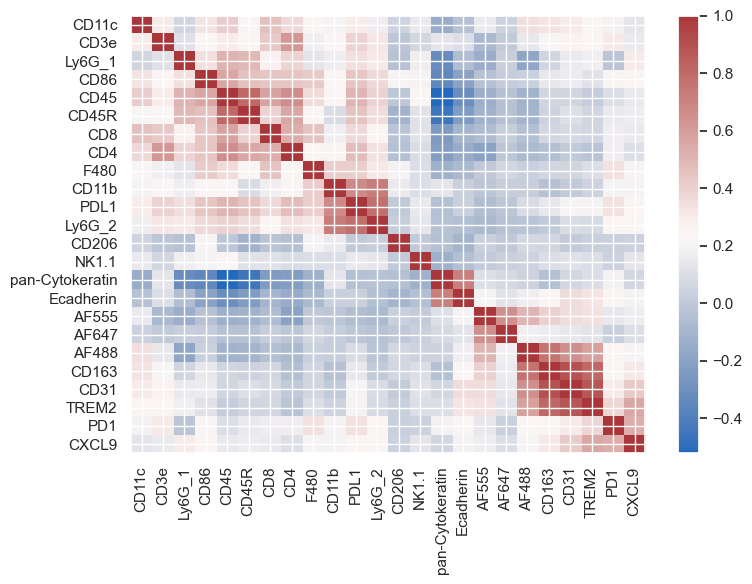

In [60]:
## Marker correlation plot -- another sanity check + good visualization on phenotyping quality
# Shows how correlated each marker is w/ every other marker across all cells
# Correlation ranges from -1 to 1:

sm.pl.markerCorrelation(
    adata,# full dataset with ALL cells
    figsize=(8, 6),  
    saveDir=None,           
    fileName=None
)

In [61]:
## Open napari to look at phenotyping results overlaid on tissue image
# 1 dot per cell -- each is colored by its assigned cell type

os.chdir(working_dir)

subset_to_use = adata.obs['imageid'].unique()[0] # get sample id again from adata

print(f"Now opening napari with phenotype overlay for: {subset_to_use}")
print("Close napari when done!")

# Same scimap plotting function, except here we have overlay=pheno_label
sm.pl.image_viewer( 
    tif_path,            
    adata,                 
    overlay=pheno_label,  # Different from before - tells napari add a colored point layer on top of tissue image where each dot = cell 
    point_size=15,         
    imageid='imageid',    
    subset=subset_to_use   
)

Now opening napari with phenotype overlay for: 41_ST_KO
Close napari when done!


## Draw Regions of Interest (ROIs)

Within each image, there will likely be multiple ROIs that we will want to analyze separately. 

For example, if a slide image contained both tumor and spleen, we would create one ROI encompassing the tumor and one encompassing the spleen. 

Using the below code, we draw our ROIs in Napari, which will automatically save the coordinates of the ROI to our <adata.obs> object.

In [63]:
## Draw ROI1
# Draw region in napari by going to shapes layer --> polygon tool; close the window when done to move on
# The region you drew gets saved as a column called "ROI1" in adata.obs

adata.obs_names_make_unique()  # Fix any duplicate cell indexes that may cause issues
os.chdir(working_dir) #navigate here first
print("Navigate to napari window and draw your region --> close napari --> then run the next cell for ROI2")

# Define the ROI label - might not want it to be "ROI1" (generic) but rather something more distinguishable


# Another scimap plot function! 
adata = sm.pl.addROI_image(
    tif_path,
    adata,
    subset=sample_id,  # sample to display
    imageid='imageid', # column to identify the sample
    overlay=pheno_label, # Show cell type colors while drawing, easier to draw meaningful regions
    overlay_category=None,  # show all categories (None means don't filter anything)
    markers=None,  # which marker channels to load (None means default)
    channel_names='default',  # use default channel naming from the tif file
    x_coordinate='X_centroid', # column in adata.obs for the cell's x position
    y_coordinate='Y_centroid', # same, but for y position
    seg_mask=None, # 
    overwrite=False, # False = don't overwrite if ROI1 already exists, set true if you need to redraw this ROI1
    label=roi_names[0]  # uses the first name from your config list
)
print(f"ROI1 has been saved to adata.obs!!")

Navigate to napari window and draw your region --> close napari --> then run the next cell for the next ROI

        Opening Napari;
        Add shape layers (on left) to draw ROI's. 
        Rename the shape layer to give a name to your ROI
        Multiple shape layers are supported
        ROI's should not overlap
        Close Napari to save ROI's.
        
Identifying cells within selected ROI's
ROIs saved under adata.obs['Tumor1']
Phenotyping saved to adata.obs!!


In [64]:
## Same thing, but draw ROI2

adata.obs_names_make_unique()
os.chdir(working_dir) 
print("Navigate to napari window and draw your region --> close napari --> then run the next cell for ROI3")

adata = sm.pl.addROI_image(
    tif_path,
    adata,
    subset=sample_id, 
    imageid='imageid', 
    overlay=pheno_label, 
    overlay_category=None, 
    markers=None, 
    channel_names='default',  
    x_coordinate='X_centroid', 
    y_coordinate='Y_centroid', 
    seg_mask=None, 
    overwrite=False, 
    label=roi_names[1]  # uses the 2nd name from your config list
)

print(" ROI2 saved to adata.obs!!")

Navigate to napari window and draw your region --> close napari --> then run the next cell for ROI3

        Opening Napari;
        Add shape layers (on left) to draw ROI's. 
        Rename the shape layer to give a name to your ROI
        Multiple shape layers are supported
        ROI's should not overlap
        Close Napari to save ROI's.
        
Identifying cells within selected ROI's
ROIs saved under adata.obs['Tumor2']
 ROI2 saved to adata.obs!!


In [65]:
## Again, same thing, but draw ROI3


os.chdir(working_dir) 
print("Navigate to napari window and draw your region --> close napari --> then run the next cell for ROI4")

adata = sm.pl.addROI_image(
    tif_path,
    adata,
    subset=sample_id, 
    imageid='imageid', 
    overlay=pheno_label, 
    overlay_category=None, 
    markers=None, 
    channel_names='default',  
    x_coordinate='X_centroid', 
    y_coordinate='Y_centroid', 
    seg_mask=None, 
    overwrite=False, 
    label=roi_names[2]  # uses the 3rd name from your config list
)
print(" ROI3 saved to adata.obs!!")

Navigate to napari window and draw your region --> close napari --> then run the next cell for ROI4

        Opening Napari;
        Add shape layers (on left) to draw ROI's. 
        Rename the shape layer to give a name to your ROI
        Multiple shape layers are supported
        ROI's should not overlap
        Close Napari to save ROI's.
        
Identifying cells within selected ROI's
ROIs saved under adata.obs['Spleen']
 ROI3 saved to adata.obs!!


In [ ]:
# ## Finally, set ROI4!


# os.chdir(working_dir) 
# print("Navigate to napari window and draw your region --> close napari")

# adata = sm.pl.addROI_image(
#     tif_path,
#     adata,
#     subset=sample_id, 
#     imageid='imageid', 
#     overlay=pheno_label, 
#     overlay_category=None, 
#     markers=None, 
#     channel_names='default',  
#     x_coordinate='X_centroid', 
#     y_coordinate='Y_centroid', 
#     seg_mask=None, 
#     overwrite=False, 
#     label=roi_names[3]  # uses the 4th name from your config list
# )
# print(" ROI4 saved to adata.obs!!")

In [66]:
# Save these ROI selections right after, b/c this is a manual step!
# Would have to redraw each ROI if there was a crash
os.chdir(analysis_dir)
adata.write(adata_checkpoint, compression=None) # overwrites previous checkpoint, now includes all 4 ROI columns in adata.obs
print(f"adata saved with ROI annotations!")


adata saved with ROI annotations!


In [72]:
## Combine each ROI column into one unified ROI column + filter to only keep cells inside your drawn regions


# Build the unified ROI column dynamically based on roi_names
# Start the new ROI column with everyone labeled "Other", then go through each ROI column and overwrite where it's applicable
adata.obs['ROI'] = 'Other'
for roi_name in roi_names:
    adata.obs.loc[adata.obs[roi_name] == roi_name, 'ROI'] = roi_name # select only rows where roi_name is the one we're iterating thru
                                                                     # set those cells' 'ROI' value to 'Tumor1' (overwrite 'Other')

# Filter adata to only cells inside the ROIs we just drew
adata1 = adata[adata.obs['ROI'].isin(roi_names)].copy() # make a copy, new one called adata1

print(f"Total cells in full adata: {adata.n_obs:,}")
print(f"Cells inside ROIs (adata1): {adata1.n_obs:,}")
print("Cells per ROI:")
print(adata1.obs['ROI'].value_counts().to_string()) #count num of times each unique value appears in the ROI column, convert to text
adata1.obs



Total cells in full adata: 1,814,113
Cells inside ROIs (adata1): 1,203,375
Cells per ROI:
ROI
Spleen    909485
Tumor2    207921
Tumor1     85969


,X_centroid,Y_centroid,Area,MajorAxisLength,MinorAxisLength,Eccentricity,Solidity,Extent,Orientation,CellID,imageid,Treatment_Group,phenotype,Tumor,Tumor1,Tumor2,Spleen,ROI
41_ST_KO_325,2037.679245,3653.084906,106.0,12.599752,10.735845,0.523431,0.929825,0.736111,0.811192,325,41_ST_KO,KS_2,Macrophages,Other,Other,Tumor2,Other,Tumor2
41_ST_KO_326,2050.380952,3669.184524,168.0,20.203279,10.659616,0.849482,0.938547,0.617647,0.804858,326,41_ST_KO,KS_2,Macrophages,Other,Other,Tumor2,Other,Tumor2
41_ST_KO_327,2011.045113,3669.345865,133.0,15.757967,10.811931,0.727484,0.917241,0.682051,-1.054332,327,41_ST_KO,KS_2,Macrophages,Other,Other,Tumor2,Other,Tumor2
41_ST_KO_328,1997.023077,3675.407692,130.0,14.474887,11.507610,0.606603,0.942029,0.714286,0.711325,328,41_ST_KO,KS_2,Macrophages,Other,Other,Tumor2,Other,Tumor2
41_ST_KO_329,2019.245614,3682.438596,114.0,14.015783,10.392592,0.670962,0.912000,0.740260,-0.218399,329,41_ST_KO,KS_2,Macrophages,Other,Other,Tumor2,Other,Tumor2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41_ST_KO_1799747,16415.553398,28989.543689,103.0,14.076392,9.950967,0.707288,0.865546,0.624242,-1.490543,1799747,41_ST_KO,KS_2,Dendritic cells,Tumor,Tumor1,Other,Other,Tumor1
41_ST_KO_1799748,16414.187500,28998.692708,192.0,20.396410,13.582947,0.745998,0.860987,0.623377,-1.468604,1799748,41_ST_KO,KS_2,Dendritic cells,Other,Tumor1,Other,Other,Tumor1
41_ST_KO_1799749,16399.503597,29000.517986,139.0,15.679027,11.554257,0.675975,0.939189,0.772222,-1.380495,1799749,41_ST_KO,KS_2,Dendritic cells,Other,Tumor1,Other,Other,Tumor1
41_ST_KO_1799750,16423.478873,29005.711268,142.0,16.927574,10.739064,0.772995,0.940397,0.682692,-1.065833,1799750,41_ST_KO,KS_2,Dendritic cells,Other,Tumor1,Other,Other,Tumor1


In [73]:
## Remove cells labeled 'Unknown' from the ROI data

before = adata1.n_obs # number of cells initially

adata1 = adata1[
    ~adata1.obs['phenotype'].isin(['Unknown']) # ~ is the NOT operator -- flips True to False, False to True
                                               # so this boolean mask is True for everything EXCEPT Unknown cells
].copy() # Creating a copy of adata1 with everything EXCEPT unknwon cells

after = adata1.n_obs


print(f"Cells before: {before:,}")
print(f"Cells after: {after:,}")


Cells before: 1,203,375
Cells after: 1,203,255


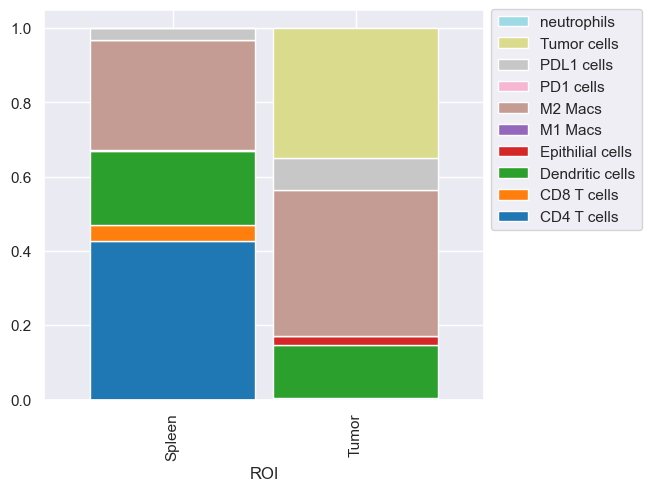

In [88]:
## Stacked bar chart, compares cell type composition between ROIs
# basically function as the earlier barplot but now we apply to adata1 (just ROIs)

sm.pl.stacked_barplot(
    adata1,              
    x_axis='ROI',        # one bar per ROI side by side
    y_axis=pheno_label,  # stack by cell type
    method='percent'     # normalize to 100% 
)

In [82]:
## Add genotype label and save the final processed file

adata1.obs['genotype'] = genotype # make new column in adata1.obs, fill every row with whatever genotype you set in configuration

adata1.write(adata_final)
print(f"Saved to: {adata_final}")

# Nice final summary!
print("STEP 1 COMPLETE")
print(f"Sample: {sample_id}")
print(f"Genotype: {genotype}")
print(f"Cells in ROIs: {adata1.n_obs:,}")
print(f"Cell types: {adata1.obs['phenotype'].nunique()}") # counts num of unique values in this column, returns a single number
print(f"Output file: {adata_final}")
print("Next, you can move onto step2_nopc_immunedensity.ipynb")

Saved to: /Users/elizabethxiu/Downloads/KS_2/analysis/scimap_results/adata_tocombine/adata_40_ST_KO.h5ad
STEP 1 COMPLETE
Sample: 40_ST_KO
Genotype: KO
Cells in ROIs: 1,000,659
Cell types: 10
Output file: /Users/elizabethxiu/Downloads/KS_2/analysis/scimap_results/adata_tocombine/adata_40_ST_KO.h5ad
Next, you can move onto step2_nopc_immunedensity.ipynb
